ESTRATEGIA: Patrones Armónicos (ABCD)

⚠️ ADVERTENCIA LEGAL: Este código es con fines educativos y de investigación. No constituye asesoramiento financiero. El trading con análisis técnico conlleva riesgo de pérdida de capital.
✅ Arquitectura base cargada desde: /media/enri/MI_PROYECTO/@Libro_estrategias_no_convencionales/core/arquitectura_base.py
📂 Directorio raíz del proyecto: /media/enri/MI_PROYECTO/@Libro_estrategias_no_convencionales

📂 GESTIÓN DE ESPACIO DE TRABAJO
  1. CSVs de Cotizaciones (Salida)  (0 archivos)
  2. CSVs de Renta 4 (Entrada)      (0 archivos)
  3. Gráficos PNG generados         (0 archivos)
  4. Carteras Excel                 (16 archivos)
  5. Limpiar TODO
  6. Omitir limpieza y continuar



¿Qué deseas vaciar? (1-6) [Por defecto 6]:  6


⏩ Limpieza omitida. Continuando...

📉 ANÁLISIS DE ESTRÉS (STRESS TESTING)
Selecciona el período histórico que deseas simular:
  1. Crisis de las Punto Com (2000-2002)
  2. Crisis Financiera Mundial (2007-2009)
  3. Crisis Deuda Soberana Europa (2010-2012)
  4. Crisis Financiera China (2015-2016)
  5. Crisis COVID-19 (2020)
  6. Subida Tipos / Inflación (2022-2023)
  7. Periodo Personalizado
  8. Histórico Completo (2018-Hoy)



Intro opción (1-8) [Por defecto 8]:  7
Introduce fecha de inicio (YYYY-MM-DD):  2016-01-04
Introduce fecha de fin (YYYY-MM-DD) o deje vacío para hoy:  2026-08-15



Descargando datos automáticamente para el experimento...

🗑️ Limpiando CSVs antiguos y descargando desde Yahoo Finance...
   Intentando descargar ^GSPC...
✅ US78462F1030.csv descargado
   Intentando descargar ^IXIC...
✅ US63110X1060.csv descargado
   Intentando descargar EURUSD=X...
✅ EURUSD.csv descargado
📝 No hay Excel cargado. Generando cartera automática (60/40) desde el diccionario...
✅ 3 activos alineados para el Motor Backtest.

🔍 Escaneando Patrones Armónicos ABCD...
  ✅ EURUSD 2019-10-01: ABCD Detectado (BC=0.66, CD=1.60)

✅ Backtest de señales generado. Inyectando en motor de métricas...

INFORME DE DIAGNÓSTICO: Patrones Armónicos ABCD (SP500)
Métrica                   | Con Rebalanceo     | Buy & Hold        
---------------------------------------------------------------------------
CAGR                      |              0.54% |             13.58%
Volatilidad               |              5.85% |             17.59%
Sharpe                    |              -0.25 |         

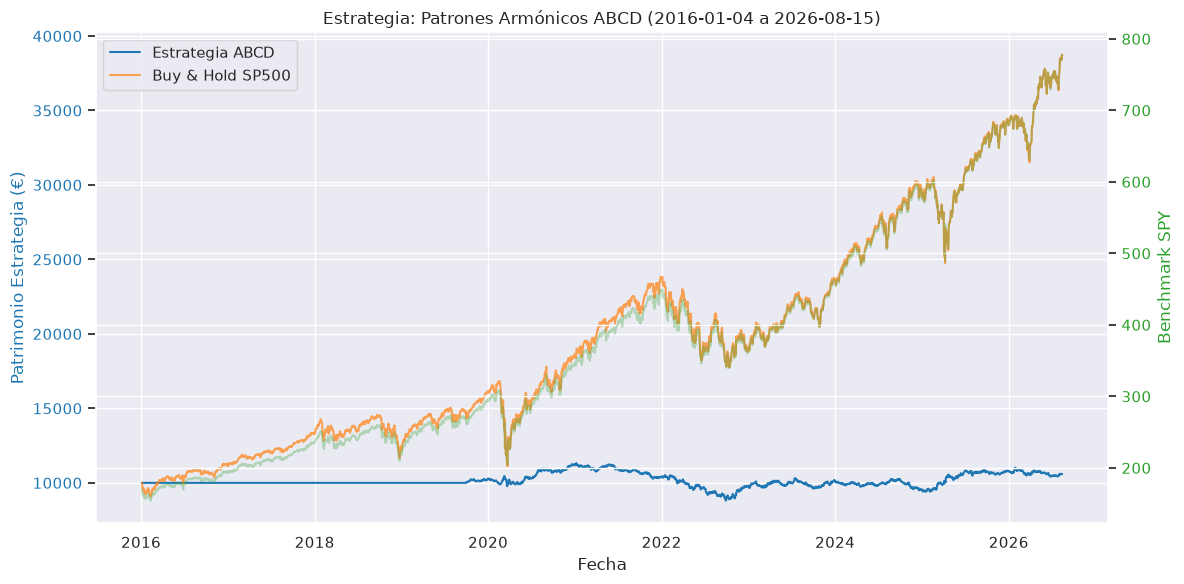


📊 MATRIZ DE CORRELACIÓN
                 Estrategia_ABCD  Buy_Hold
Estrategia_ABCD             1.00      0.01
Buy_Hold                    0.01      1.00


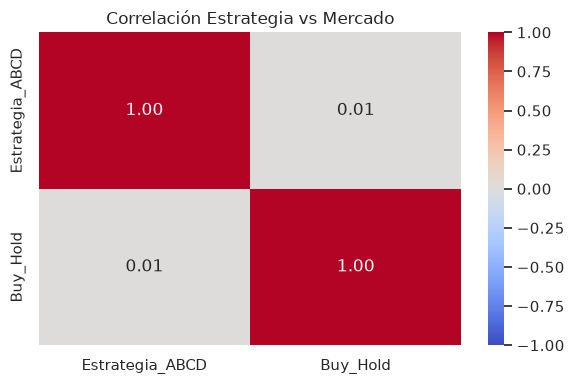


✅ Ejecución completada con éxito.


In [1]:
# ==========================================================================
# ESTRATEGIA: Patrones Armónicos (ABCD)
# VERSIÓN: V3.2 (Rutas Dinámicas Portables)
# ==========================================================================

# BLOQUE 0: Configuración de la Estrategia
# --------------------------------------------------------------------------
CAPITAL_INICIAL = 10000
APORTACION_MENSUAL = 0
COSTE_TRANSACCION = 0.001 
FREQ_REBALANCEO = 'D' 
BENCHMARK = "SPY"

RUTA_ENTRADA_R4 = None
RUTA_SALIDA_CSV = None

DICCIONARIO_DATOS = {
    'INDICES': {
        'SP500': {'isin': 'US78462F1030', 'ticker': '^GSPC'},
        'NASDAQ': {'isin': 'US63110X1060', 'ticker': '^IXIC'}
    },
    'DIVISAS': {
        'EURUSD': {'isin': 'EURUSD', 'ticker': 'EURUSD=X'}
    }
}

# BLOQUE 1: Entorno y Importaciones (Rutas Dinámicas)
# --------------------------------------------------------------------------
print("⚠️ ADVERTENCIA LEGAL: Este código es con fines educativos y de investigación. No constituye asesoramiento financiero. El trading con análisis técnico conlleva riesgo de pérdida de capital.")

import os
import sys
import subprocess
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import argrelextrema

try:
    from sqlalchemy import create_engine
    import openpyxl
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "sqlalchemy", "openpyxl", "scipy"])
    from sqlalchemy import create_engine
    import openpyxl

# Detección de entorno y ruta base dinámica
def obtener_ruta_base():
    # Si estamos en Google Colab
    try:
        import google.colab
        from google.colab import drive
        drive.mount('/content/drive')
        return Path("/content/drive/MyDrive/MI_PROYECTO/@Libro_estrategias_no_convencionales")
    except:
        pass
    
    # Si estamos en Local: Buscar la carpeta 'core' hacia arriba
    ruta_actual = Path(os.getcwd()).resolve()
    for _ in range(5): # Sube hasta 5 niveles de directorios
        if (ruta_actual / "core" / "arquitectura_base.py").exists():
            return ruta_actual
        ruta_actual = ruta_actual.parent
    
    # Fallback: si no encuentra 'core', asume que el notebook está en la raíz
    return Path(os.getcwd()).resolve()

RUTA_BASE = obtener_ruta_base()
sys.path.append(str(RUTA_BASE / "core"))

ruta_arquitectura = RUTA_BASE / "core" / "arquitectura_base.py"
if ruta_arquitectura.exists():
    try:
        from arquitectura_base import GestorDatos, MotorBacktest, CalculadorMetricas, GeneradorInformes
        print(f"✅ Arquitectura base cargada desde: {ruta_arquitectura}")
        print(f"📂 Directorio raíz del proyecto: {RUTA_BASE}")
    except Exception as e:
        print(f"❌ Se encontró el archivo pero hubo un error al importar: {e}")
else:
    print(f"❌ ERROR: No se encuentra 'arquitectura_base.py' en {ruta_arquitectura}")
    print("Asegúrate de que este notebook se está ejecutando dentro de la carpeta del proyecto o una subcarpeta suya.")

# BLOQUE 2: Limpieza de Directorios (Primer Menú)
# --------------------------------------------------------------------------
def limpiar_directorios():
    print("\n" + "="*55)
    print("📂 GESTIÓN DE ESPACIO DE TRABAJO")
    print("="*55)
    
    dir_csv = RUTA_BASE / "datos" / "datos_csv"
    dir_r4 = RUTA_BASE / "datos" / "datos_fi_r4"
    dir_png = RUTA_BASE / "outputs" / "figures" / "png"
    dir_exc = RUTA_BASE / "carteras"
    
    for d in [dir_csv, dir_r4, dir_png, dir_exc]: d.mkdir(parents=True, exist_ok=True)
    
    def count_files(d): return len(list(d.glob("*")))
    
    print(f"  1. CSVs de Cotizaciones (Salida)  ({count_files(dir_csv)} archivos)")
    print(f"  2. CSVs de Renta 4 (Entrada)      ({count_files(dir_r4)} archivos)")
    print(f"  3. Gráficos PNG generados         ({count_files(dir_png)} archivos)")
    print(f"  4. Carteras Excel                 ({count_files(dir_exc)} archivos)")
    print("  5. Limpiar TODO")
    print("  6. Omitir limpieza y continuar")
    
    sel = input("\n¿Qué deseas vaciar? (1-6) [Por defecto 6]: ").strip() or "6"
    
    rutas = {"1": dir_csv, "2": dir_r4, "3": dir_png, "4": dir_exc}
    
    if sel == "5":
        for ruta in rutas.values():
            for f in ruta.glob("*"):
                if f.is_file(): f.unlink()
        print("✅ Todas las carpetas limpiadas.")
    elif sel in rutas:
        for f in rutas[sel].glob("*"):
            if f.is_file(): f.unlink()
        print(f"✅ Carpeta {sel} limpiada.")
    else:
        print("⏩ Limpieza omitida. Continuando...")

limpiar_directorios()

# BLOQUE 3: Gestión de Fechas (Menú de Estrés)
# --------------------------------------------------------------------------
def menu_fechas():
    print("\n" + "="*70)
    print("📉 ANÁLISIS DE ESTRÉS (STRESS TESTING)")
    print("="*70)
    print("Selecciona el período histórico que deseas simular:")
    print("  1. Crisis de las Punto Com (2000-2002)")
    print("  2. Crisis Financiera Mundial (2007-2009)")
    print("  3. Crisis Deuda Soberana Europa (2010-2012)")
    print("  4. Crisis Financiera China (2015-2016)")
    print("  5. Crisis COVID-19 (2020)")
    print("  6. Subida Tipos / Inflación (2022-2023)")
    print("  7. Periodo Personalizado")
    print("  8. Histórico Completo (2018-Hoy)")
    
    sel = input("\nIntro opción (1-8) [Por defecto 8]: ").strip() or "8"
    
    periodos = {
        "1": ("2000-03-01", "2002-12-01"),
        "2": ("2007-10-01", "2009-04-01"),
        "3": ("2010-01-01", "2012-12-31"),
        "4": ("2015-06-01", "2016-06-01"),
        "5": ("2020-02-01", "2020-08-01"),
        "6": ("2022-01-01", "2023-06-01"),
        "8": ("2018-01-01", pd.Timestamp.now().strftime('%Y-%m-%d'))
    }
    
    if sel == "7":
        ini = input("Introduce fecha de inicio (YYYY-MM-DD): ")
        fin = input("Introduce fecha de fin (YYYY-MM-DD) o deje vacío para hoy: ")
        return ini, fin or pd.Timestamp.now().strftime('%Y-%m-%d')
    elif sel in periodos:
        return periodos[sel]
    else:
        return periodos["8"]

fecha_inicio, fecha_fin = menu_fechas()

# BLOQUE 4: Menú del Gestor de Datos
# --------------------------------------------------------------------------
gestor = GestorDatos(
    diccionario_datos=DICCIONARIO_DATOS,
    dir_base=str(RUTA_BASE),
    fecha_inicio=fecha_inicio,
    fecha_fin=fecha_fin,
    ruta_entrada_r4=RUTA_ENTRADA_R4,
    ruta_salida_csv=RUTA_SALIDA_CSV
)

print("\nDescargando datos automáticamente para el experimento...")
gestor.gestionar_descarga_cotizaciones()
gestor._cartera_por_defecto()
gestor.preparar_datos_motor()

# BLOQUE 5: Preparación de Pesos (Lógica de la Estrategia Armónica) ⚠️
# --------------------------------------------------------------------------
class HarmonicScanner:
    def __init__(self, precios, tol=0.05):
        self.precios = precios
        self.tol = tol 
        self.signals = pd.DataFrame(index=precios.index, columns=precios.columns, data=0.0)

    def _find_pivots(self, series):
        order = 5
        max_idx = argrelextrema(series.values, np.greater, order=order)[0]
        min_idx = argrelextrema(series.values, np.less, order=order)[0]
        return min_idx, max_idx

    def scan_abcd(self):
        print("\n🔍 Escaneando Patrones Armónicos ABCD...")
        for col in self.precios.columns:
            series = self.precios[col].dropna()
            if len(series) < 50: continue
            
            min_idx, max_idx = self._find_pivots(series)
            pivots = sorted(list(min_idx) + list(max_idx))
            
            for i in range(len(pivots) - 3):
                A, B, C, D = pivots[i], pivots[i+1], pivots[i+2], pivots[i+3]
                pA, pB, pC, pD = series.iloc[A], series.iloc[B], series.iloc[C], series.iloc[D]
                
                if not ((pB > pA and pC < pB and pD > pC) or (pB < pA and pC > pB and pD < pC)):
                    continue
                
                AB = abs(pB - pA)
                BC = abs(pC - pB)
                CD = abs(pD - pC)
                retrace_bc = BC / AB if AB > 0 else 0
                ext_cd = CD / BC if BC > 0 else 0
                
                if abs(retrace_bc - 0.618) <= self.tol and abs(ext_cd - 1.618) <= self.tol:
                    if pD < pC: 
                        self.signals.iloc[D, self.precios.columns.get_loc(col)] = 1.0
                    else: 
                        self.signals.iloc[D, self.precios.columns.get_loc(col)] = -1.0
                    print(f"  ✅ {col} {series.index[D].date()}: ABCD Detectado (BC={retrace_bc:.2f}, CD={ext_cd:.2f})")
                    
            estado = 0
            for j in range(len(self.signals)):
                if self.signals.iloc[j, self.precios.columns.get_loc(col)] != 0:
                    estado = self.signals.iloc[j, self.precios.columns.get_loc(col)]
                self.signals.iloc[j, self.precios.columns.get_loc(col)] = estado

scanner = HarmonicScanner(gestor.precios_ajustados)
scanner.scan_abcd()

retornos_diarios = gestor.rentabilidades_diarias
signals = scanner.signals

retornos_estrategia = (retornos_diarios * signals.shift(1).fillna(0)).sum(axis=1)
serie_patrimonio_estrategia = CAPITAL_INICIAL * (1 + retornos_estrategia).cumprod()

benchmark_col = 'SP500' if 'SP500' in retornos_diarios.columns else retornos_diarios.columns[0]
serie_buy_hold = CAPITAL_INICIAL * (1 + retornos_diarios[benchmark_col]).cumprod()

print("\n✅ Backtest de señales generado. Inyectando en motor de métricas...")

# BLOQUE 6: Ejecución del Motor de Backtest
# --------------------------------------------------------------------------
try:
    import yfinance as yf
    bench = yf.download(BENCHMARK, start=fecha_inicio, end=fecha_fin, progress=False, auto_adjust=True)
    serie_benchmark = bench['Close'].squeeze()
except:
    serie_benchmark = None

# BLOQUE 7: Métricas e Informes
# --------------------------------------------------------------------------
calculador = CalculadorMetricas(
    serie_patrimonio=serie_patrimonio_estrategia, 
    serie_buy_hold=serie_buy_hold,
    serie_benchmark=serie_benchmark
)

metricas = calculador.calcular_todas_las_metricas()

generador = GeneradorInformes(
    serie_patrimonio=serie_patrimonio_estrategia,
    metricas=metricas,
    nombre_estrategia=f"Patrones Armónicos ABCD ({benchmark_col})",
    serie_buy_hold=serie_buy_hold,
    log_transacciones=[],
    pesos_actuales={"Estrategia": 1.0},
    pesos_ideales={"Estrategia": 1.0}
)

generador.imprimir_metricas()
print(calculador.diagnosticar())

# BLOQUE 8: Visualización y Guardado de Gráficos
# --------------------------------------------------------------------------
sns.set_theme(style="darkgrid")
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Patrimonio Estrategia (€)', color=color)
ax1.plot(serie_patrimonio_estrategia.index, serie_patrimonio_estrategia, color=color, label='Estrategia ABCD')
ax1.plot(serie_buy_hold.index, serie_buy_hold, color='tab:orange', alpha=0.7, label=f'Buy & Hold {benchmark_col}')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()  
color = 'tab:green'
ax2.set_ylabel('Benchmark SPY', color=color)  
if serie_benchmark is not None:
    ax2.plot(serie_benchmark.index, serie_benchmark, color=color, alpha=0.3, label='SPY Benchmark')
ax2.tick_params(axis='y', labelcolor=color)

plt.title(f"Estrategia: Patrones Armónicos ABCD ({fecha_inicio} a {fecha_fin})")
fig.tight_layout()

ruta_guardado = RUTA_BASE / "outputs" / "figures" / "png" / "patrones_armonicos_abcd.png"
plt.savefig(ruta_guardado, dpi=300)
print(f"\n📊 Gráfico guardado en: {ruta_guardado}")
plt.show()

# BLOQUE 9: Análisis de Correlación Final
# --------------------------------------------------------------------------
print("\n" + "="*55 + "\n📊 MATRIZ DE CORRELACIÓN\n" + "="*55)
df_corr = pd.DataFrame({
    'Estrategia_ABCD': serie_patrimonio_estrategia.pct_change().dropna(),
    'Buy_Hold': serie_buy_hold.pct_change().dropna()
})
corr_matrix = df_corr.corr()
print(corr_matrix.round(2).to_string())

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlación Estrategia vs Mercado")
plt.tight_layout()
plt.show()
print("\n✅ Ejecución completada con éxito.")

⚠️ ADVERTENCIA LEGAL: Este código es con fines educativos y de investigación. No constituye asesoramiento financiero. El trading con análisis técnico conlleva riesgo de pérdida de capital.
✅ Arquitectura base cargada desde: /media/enri/MI_PROYECTO/@Libro_estrategias_no_convencionales/core/arquitectura_base.py
📂 Directorio raíz del proyecto: /media/enri/MI_PROYECTO/@Libro_estrategias_no_convencionales

📂 GESTIÓN DE ESPACIO DE TRABAJO
  1. CSVs de Cotizaciones (Salida)  (3 archivos)
  2. CSVs de Renta 4 (Entrada)      (0 archivos)
  3. Gráficos PNG generados         (1 archivos)
  4. Carteras Excel                 (16 archivos)
  5. Limpiar TODO
  6. Omitir limpieza y continuar



¿Qué deseas vaciar? (1-6) [Por defecto 6]:  6


⏩ Limpieza omitida. Continuando...

📉 ANÁLISIS DE ESTRÉS (STRESS TESTING)
Selecciona el período histórico que deseas simular:
  1. Crisis de las Punto Com (2000-2002)
  2. Crisis Financiera Mundial (2007-2009)
  3. Crisis Deuda Soberana Europa (2010-2012)
  4. Crisis Financiera China (2015-2016)
  5. Crisis COVID-19 (2020)
  6. Subida Tipos / Inflación (2022-2023)
  7. Periodo Personalizado
  8. Histórico Completo (2018-Hoy)



Intro opción (1-8) [Por defecto 8]:  7
Introduce fecha de inicio (YYYY-MM-DD):  2016-01-04
Introduce fecha de fin (YYYY-MM-DD) o deje vacío para hoy:  2026-08-15



Descargando datos automáticamente para el experimento...

🗑️ Limpiando CSVs antiguos y descargando desde Yahoo Finance...
   Intentando descargar ^GSPC...
✅ US78462F1030.csv descargado
   Intentando descargar ^IXIC...
✅ US63110X1060.csv descargado
   Intentando descargar EURUSD=X...
✅ EURUSD.csv descargado
📝 No hay Excel cargado. Generando cartera automática (60/40) desde el diccionario...
✅ 3 activos alineados para el Motor Backtest.

🔍 Escaneando Patrones Armónicos ABCD (Manteniendo 5 días)...
  ✅ SP500 2016-05-19: ABCD (BC=0.531, CD=1.328) -> LONG
  ✅ SP500 2016-09-06: ABCD (BC=0.839, CD=1.641) -> SHORT
  ✅ SP500 2017-08-18: ABCD (BC=0.700, CD=1.423) -> LONG
  ✅ SP500 2017-10-27: ABCD (BC=0.780, CD=1.324) -> SHORT
  ✅ SP500 2019-03-01: ABCD (BC=0.547, CD=1.652) -> SHORT
  ✅ SP500 2020-04-29: ABCD (BC=0.342, CD=1.471) -> SHORT
  ✅ SP500 2020-12-17: ABCD (BC=0.679, CD=1.369) -> SHORT
  ✅ SP500 2021-05-07: ABCD (BC=0.612, CD=1.451) -> SHORT
  ✅ SP500 2021-06-03: ABCD (BC=0.525, CD=1.3

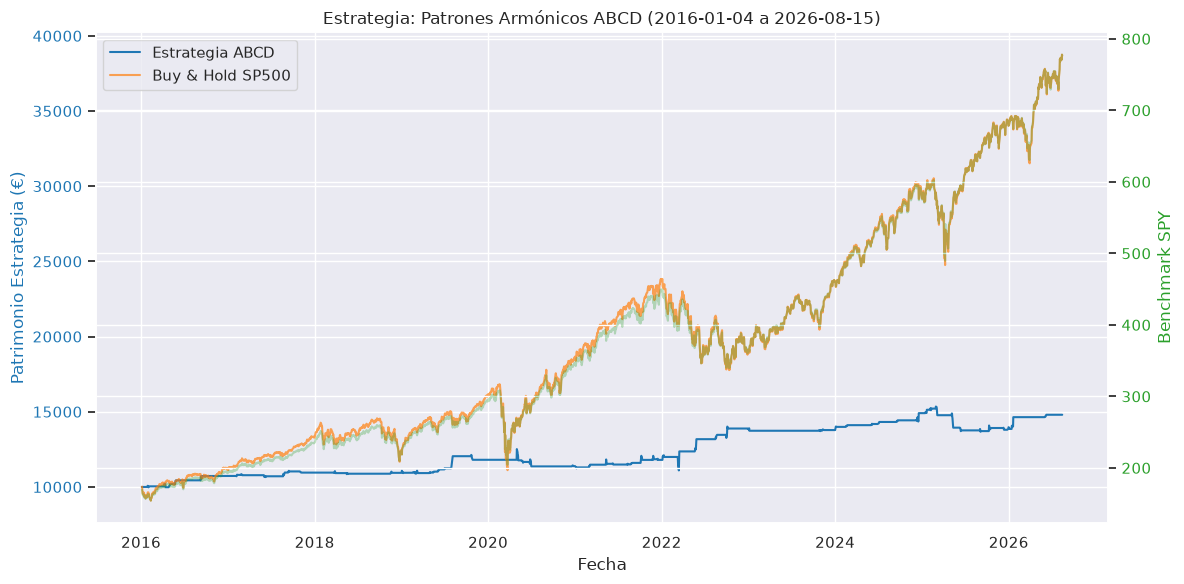


📊 MATRIZ DE CORRELACIÓN
                 Estrategia_ABCD  Buy_Hold
Estrategia_ABCD             1.00     -0.06
Buy_Hold                   -0.06      1.00


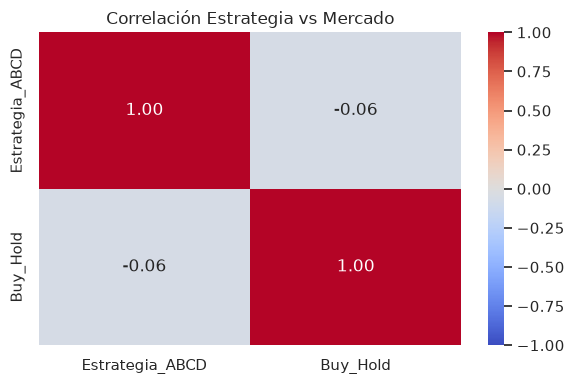


✅ Ejecución completada con éxito.


In [3]:
# ==========================================================================
# ESTRATEGIA: Patrones Armónicos (ABCD)
# VERSIÓN: V3.2 (Rutas Dinámicas Portables)
# ==========================================================================

# BLOQUE 0: Configuración de la Estrategia
# --------------------------------------------------------------------------
CAPITAL_INICIAL = 10000
APORTACION_MENSUAL = 0
COSTE_TRANSACCION = 0.001 
FREQ_REBALANCEO = 'D' 
BENCHMARK = "SPY"

RUTA_ENTRADA_R4 = None
RUTA_SALIDA_CSV = None

DICCIONARIO_DATOS = {
    'INDICES': {
        'SP500': {'isin': 'US78462F1030', 'ticker': '^GSPC'},
        'NASDAQ': {'isin': 'US63110X1060', 'ticker': '^IXIC'}
    },
    'DIVISAS': {
        'EURUSD': {'isin': 'EURUSD', 'ticker': 'EURUSD=X'}
    }
}

# BLOQUE 1: Entorno y Importaciones (Rutas Dinámicas)
# --------------------------------------------------------------------------
print("⚠️ ADVERTENCIA LEGAL: Este código es con fines educativos y de investigación. No constituye asesoramiento financiero. El trading con análisis técnico conlleva riesgo de pérdida de capital.")

import os
import sys
import subprocess
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import argrelextrema

try:
    from sqlalchemy import create_engine
    import openpyxl
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "sqlalchemy", "openpyxl", "scipy"])
    from sqlalchemy import create_engine
    import openpyxl

# Detección de entorno y ruta base dinámica
def obtener_ruta_base():
    # Si estamos en Google Colab
    try:
        import google.colab
        from google.colab import drive
        drive.mount('/content/drive')
        return Path("/content/drive/MyDrive/MI_PROYECTO/@Libro_estrategias_no_convencionales")
    except:
        pass
    
    # Si estamos en Local: Buscar la carpeta 'core' hacia arriba
    ruta_actual = Path(os.getcwd()).resolve()
    for _ in range(5): # Sube hasta 5 niveles de directorios
        if (ruta_actual / "core" / "arquitectura_base.py").exists():
            return ruta_actual
        ruta_actual = ruta_actual.parent
    
    # Fallback: si no encuentra 'core', asume que el notebook está en la raíz
    return Path(os.getcwd()).resolve()

RUTA_BASE = obtener_ruta_base()
sys.path.append(str(RUTA_BASE / "core"))

ruta_arquitectura = RUTA_BASE / "core" / "arquitectura_base.py"
if ruta_arquitectura.exists():
    try:
        from arquitectura_base import GestorDatos, MotorBacktest, CalculadorMetricas, GeneradorInformes
        print(f"✅ Arquitectura base cargada desde: {ruta_arquitectura}")
        print(f"📂 Directorio raíz del proyecto: {RUTA_BASE}")
    except Exception as e:
        print(f"❌ Se encontró el archivo pero hubo un error al importar: {e}")
else:
    print(f"❌ ERROR: No se encuentra 'arquitectura_base.py' en {ruta_arquitectura}")
    print("Asegúrate de que este notebook se está ejecutando dentro de la carpeta del proyecto o una subcarpeta suya.")

# BLOQUE 2: Limpieza de Directorios (Primer Menú)
# --------------------------------------------------------------------------
def limpiar_directorios():
    print("\n" + "="*55)
    print("📂 GESTIÓN DE ESPACIO DE TRABAJO")
    print("="*55)
    
    dir_csv = RUTA_BASE / "datos" / "datos_csv"
    dir_r4 = RUTA_BASE / "datos" / "datos_fi_r4"
    dir_png = RUTA_BASE / "outputs" / "figures" / "png"
    dir_exc = RUTA_BASE / "carteras"
    
    for d in [dir_csv, dir_r4, dir_png, dir_exc]: d.mkdir(parents=True, exist_ok=True)
    
    def count_files(d): return len(list(d.glob("*")))
    
    print(f"  1. CSVs de Cotizaciones (Salida)  ({count_files(dir_csv)} archivos)")
    print(f"  2. CSVs de Renta 4 (Entrada)      ({count_files(dir_r4)} archivos)")
    print(f"  3. Gráficos PNG generados         ({count_files(dir_png)} archivos)")
    print(f"  4. Carteras Excel                 ({count_files(dir_exc)} archivos)")
    print("  5. Limpiar TODO")
    print("  6. Omitir limpieza y continuar")
    
    sel = input("\n¿Qué deseas vaciar? (1-6) [Por defecto 6]: ").strip() or "6"
    
    rutas = {"1": dir_csv, "2": dir_r4, "3": dir_png, "4": dir_exc}
    
    if sel == "5":
        for ruta in rutas.values():
            for f in ruta.glob("*"):
                if f.is_file(): f.unlink()
        print("✅ Todas las carpetas limpiadas.")
    elif sel in rutas:
        for f in rutas[sel].glob("*"):
            if f.is_file(): f.unlink()
        print(f"✅ Carpeta {sel} limpiada.")
    else:
        print("⏩ Limpieza omitida. Continuando...")

limpiar_directorios()

# BLOQUE 3: Gestión de Fechas (Menú de Estrés)
# --------------------------------------------------------------------------
def menu_fechas():
    print("\n" + "="*70)
    print("📉 ANÁLISIS DE ESTRÉS (STRESS TESTING)")
    print("="*70)
    print("Selecciona el período histórico que deseas simular:")
    print("  1. Crisis de las Punto Com (2000-2002)")
    print("  2. Crisis Financiera Mundial (2007-2009)")
    print("  3. Crisis Deuda Soberana Europa (2010-2012)")
    print("  4. Crisis Financiera China (2015-2016)")
    print("  5. Crisis COVID-19 (2020)")
    print("  6. Subida Tipos / Inflación (2022-2023)")
    print("  7. Periodo Personalizado")
    print("  8. Histórico Completo (2018-Hoy)")
    
    sel = input("\nIntro opción (1-8) [Por defecto 8]: ").strip() or "8"
    
    periodos = {
        "1": ("2000-03-01", "2002-12-01"),
        "2": ("2007-10-01", "2009-04-01"),
        "3": ("2010-01-01", "2012-12-31"),
        "4": ("2015-06-01", "2016-06-01"),
        "5": ("2020-02-01", "2020-08-01"),
        "6": ("2022-01-01", "2023-06-01"),
        "8": ("2018-01-01", pd.Timestamp.now().strftime('%Y-%m-%d'))
    }
    
    if sel == "7":
        ini = input("Introduce fecha de inicio (YYYY-MM-DD): ")
        fin = input("Introduce fecha de fin (YYYY-MM-DD) o deje vacío para hoy: ")
        return ini, fin or pd.Timestamp.now().strftime('%Y-%m-%d')
    elif sel in periodos:
        return periodos[sel]
    else:
        return periodos["8"]

fecha_inicio, fecha_fin = menu_fechas()

# BLOQUE 4: Menú del Gestor de Datos
# --------------------------------------------------------------------------
gestor = GestorDatos(
    diccionario_datos=DICCIONARIO_DATOS,
    dir_base=str(RUTA_BASE),
    fecha_inicio=fecha_inicio,
    fecha_fin=fecha_fin,
    ruta_entrada_r4=RUTA_ENTRADA_R4,
    ruta_salida_csv=RUTA_SALIDA_CSV
)

print("\nDescargando datos automáticamente para el experimento...")
gestor.gestionar_descarga_cotizaciones()
gestor._cartera_por_defecto()
gestor.preparar_datos_motor()

# BLOQUE 5: Preparación de Pesos (Lógica de la Estrategia Armónica) ⚠️
# --------------------------------------------------------------------------
class HarmonicScanner:
    def __init__(self, precios, tol=0.10, hold_days=5):
        self.precios = precios
        self.tol = tol 
        self.hold_days = hold_days # Días que mantenemos la operación abierta
        self.valid_bc_ratios = [0.382, 0.500, 0.618, 0.786]
        self.valid_cd_ratios = [1.272, 1.414, 1.618]
        self.signals = pd.DataFrame(index=precios.index, columns=precios.columns, data=0.0)

    def _find_pivots(self, series):
        order = 3
        max_idx = argrelextrema(series.values, np.greater, order=order)[0]
        min_idx = argrelextrema(series.values, np.less, order=order)[0]
        return min_idx, max_idx

    def scan_abcd(self):
        print(f"\n🔍 Escaneando Patrones Armónicos ABCD (Manteniendo {self.hold_days} días)...")
        total_patrones = 0
        for col in self.precios.columns:
            series = self.precios[col].dropna()
            if len(series) < 50: continue
            
            min_idx, max_idx = self._find_pivots(series)
            pivots = sorted(list(min_idx) + list(max_idx))
            
            for i in range(len(pivots) - 3):
                A, B, C, D = pivots[i], pivots[i+1], pivots[i+2], pivots[i+3]
                pA, pB, pC, pD = series.iloc[A], series.iloc[B], series.iloc[C], series.iloc[D]
                
                if not ((pB > pA and pC < pB and pD > pC) or (pB < pA and pC > pB and pD < pC)):
                    continue
                
                AB = abs(pB - pA)
                BC = abs(pC - pB)
                CD = abs(pD - pC)
                retrace_bc = BC / AB if AB > 0 else 0
                ext_cd = CD / BC if BC > 0 else 0
                
                is_valid_bc = any(abs(retrace_bc - r) <= self.tol for r in self.valid_bc_ratios)
                is_valid_cd = any(abs(ext_cd - r) <= self.tol for r in self.valid_cd_ratios)
                
                if is_valid_bc and is_valid_cd:
                    total_patrones += 1
                    direction = 1.0 if pD < pC else -1.0
                    print(f"  ✅ {col} {series.index[D].date()}: ABCD (BC={retrace_bc:.3f}, CD={ext_cd:.3f}) -> {'LONG' if direction==1 else 'SHORT'}")
                    
                    # GESTIÓN DE LA SEÑAL: Entramos un día después de D (shift(1) en el backtest)
                    # y mantenemos la posición solo 'hold_days'
                    start_pos = self.precios.index.get_loc(series.index[D])
                    col_idx = self.precios.columns.get_loc(col)
                    for d in range(1, self.hold_days + 1):
                        if start_pos + d < len(self.signals):
                            self.signals.iloc[start_pos + d, col_idx] = direction
                            
            print(f"📊 Total de patrones detectados en {col}: {sum(self.signals[col] != 0)} señales de trading.")

scanner = HarmonicScanner(gestor.precios_ajustados, hold_days=5)
scanner.scan_abcd()

retornos_diarios = gestor.rentabilidades_diarias
signals = scanner.signals

# Calculamos los retornos de la estrategia
retornos_estrategia = (retornos_diarios * signals.shift(1).fillna(0)).sum(axis=1)
serie_patrimonio_estrategia = CAPITAL_INICIAL * (1 + retornos_estrategia).cumprod()

# Comparativa Buy & Hold
benchmark_col = 'SP500' if 'SP500' in retornos_diarios.columns else retornos_diarios.columns[0]
serie_buy_hold = CAPITAL_INICIAL * (1 + retornos_diarios[benchmark_col]).cumprod()

print("\n✅ Backtest de señales generado. Inyectando en motor de métricas...")

scanner = HarmonicScanner(gestor.precios_ajustados)
scanner.scan_abcd()

retornos_diarios = gestor.rentabilidades_diarias
signals = scanner.signals

# Aquí aplicamos la señal de trading (1=Long, -1=Short, 0=Flat)
retornos_estrategia = (retornos_diarios * signals.shift(1).fillna(0)).sum(axis=1)
serie_patrimonio_estrategia = CAPITAL_INICIAL * (1 + retornos_estrategia).cumprod()

# Comparativa Buy & Hold
benchmark_col = 'SP500' if 'SP500' in retornos_diarios.columns else retornos_diarios.columns[0]
serie_buy_hold = CAPITAL_INICIAL * (1 + retornos_diarios[benchmark_col]).cumprod()

print("\n✅ Backtest de señales generado. Inyectando en motor de métricas...")

scanner = HarmonicScanner(gestor.precios_ajustados)
scanner.scan_abcd()

retornos_diarios = gestor.rentabilidades_diarias
signals = scanner.signals

retornos_estrategia = (retornos_diarios * signals.shift(1).fillna(0)).sum(axis=1)
serie_patrimonio_estrategia = CAPITAL_INICIAL * (1 + retornos_estrategia).cumprod()

benchmark_col = 'SP500' if 'SP500' in retornos_diarios.columns else retornos_diarios.columns[0]
serie_buy_hold = CAPITAL_INICIAL * (1 + retornos_diarios[benchmark_col]).cumprod()

print("\n✅ Backtest de señales generado. Inyectando en motor de métricas...")

# BLOQUE 6: Ejecución del Motor de Backtest
# --------------------------------------------------------------------------
try:
    import yfinance as yf
    bench = yf.download(BENCHMARK, start=fecha_inicio, end=fecha_fin, progress=False, auto_adjust=True)
    serie_benchmark = bench['Close'].squeeze()
except:
    serie_benchmark = None

# BLOQUE 7: Métricas e Informes
# --------------------------------------------------------------------------
calculador = CalculadorMetricas(
    serie_patrimonio=serie_patrimonio_estrategia, 
    serie_buy_hold=serie_buy_hold,
    serie_benchmark=serie_benchmark
)

metricas = calculador.calcular_todas_las_metricas()

generador = GeneradorInformes(
    serie_patrimonio=serie_patrimonio_estrategia,
    metricas=metricas,
    nombre_estrategia=f"Patrones Armónicos ABCD ({benchmark_col})",
    serie_buy_hold=serie_buy_hold,
    log_transacciones=[],
    pesos_actuales={"Estrategia": 1.0},
    pesos_ideales={"Estrategia": 1.0}
)

generador.imprimir_metricas()
print(calculador.diagnosticar())

# BLOQUE 8: Visualización y Guardado de Gráficos
# --------------------------------------------------------------------------
sns.set_theme(style="darkgrid")
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Patrimonio Estrategia (€)', color=color)
ax1.plot(serie_patrimonio_estrategia.index, serie_patrimonio_estrategia, color=color, label='Estrategia ABCD')
ax1.plot(serie_buy_hold.index, serie_buy_hold, color='tab:orange', alpha=0.7, label=f'Buy & Hold {benchmark_col}')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()  
color = 'tab:green'
ax2.set_ylabel('Benchmark SPY', color=color)  
if serie_benchmark is not None:
    ax2.plot(serie_benchmark.index, serie_benchmark, color=color, alpha=0.3, label='SPY Benchmark')
ax2.tick_params(axis='y', labelcolor=color)

plt.title(f"Estrategia: Patrones Armónicos ABCD ({fecha_inicio} a {fecha_fin})")
fig.tight_layout()

ruta_guardado = RUTA_BASE / "outputs" / "figures" / "png" / "patrones_armonicos_abcd.png"
plt.savefig(ruta_guardado, dpi=300)
print(f"\n📊 Gráfico guardado en: {ruta_guardado}")
plt.show()

# BLOQUE 9: Análisis de Correlación Final
# --------------------------------------------------------------------------
print("\n" + "="*55 + "\n📊 MATRIZ DE CORRELACIÓN\n" + "="*55)
df_corr = pd.DataFrame({
    'Estrategia_ABCD': serie_patrimonio_estrategia.pct_change().dropna(),
    'Buy_Hold': serie_buy_hold.pct_change().dropna()
})
corr_matrix = df_corr.corr()
print(corr_matrix.round(2).to_string())

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlación Estrategia vs Mercado")
plt.tight_layout()
plt.show()
print("\n✅ Ejecución completada con éxito.")